# Run at First Time: nltk

In [ ]:
# import nltk
# nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /home/jiahao/nltk_data...


True

# model debug

In [ ]:
import numpy as np
from ruamel.yaml import YAML
yaml = YAML(typ='safe')

import torch
from models.model_search import Search

/home/jiahao/miniconda3/envs/cmp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = yaml.load(open('configs/tta_debug.yaml', 'r'))

model = Search(config=config)


/home/jiahao/miniconda3/envs/cmp/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


build_vision_encoder: load swin 224 x 224 ====>
missing_keys:  []
unexpected_keys:  ['head.weight', 'head.bias']
meta
meta
meta
meta
build_text_encoder: load bert ====>
missing_keys: ['bert.encoder.layer.10.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.10.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.10.crossattention.output.dense.bias', 'bert.encoder.layer.10.crossattention.output.dense.weight', 'bert.encoder.layer.10.crossattention.self.key.bias', 'bert.encoder.layer.10.crossattention.self.key.weight', 'bert.encoder.layer.10.crossattention.self.query.bias', 'bert.encoder.layer.10.crossattention.self.query.weight', 'bert.encoder.layer.10.crossattention.self.value.bias', 'bert.encoder.layer.10.crossattention.self.value.weight', 'bert.encoder.layer.11.crossattention.output.LayerNorm.bias', 'bert.encoder.layer.11.crossattention.output.LayerNorm.weight', 'bert.encoder.layer.11.crossattention.output.dense.bias', 'bert.encoder.layer.11.crossattention.output.dense

In [3]:
for n,m in model.named_parameters():
    print(n, m.device)

temp cpu
vision_encoder.patch_embed.proj.weight cpu
vision_encoder.patch_embed.proj.bias cpu
vision_encoder.patch_embed.norm.weight cpu
vision_encoder.patch_embed.norm.bias cpu
vision_encoder.layers.0.blocks.0.norm1.weight cpu
vision_encoder.layers.0.blocks.0.norm1.bias cpu
vision_encoder.layers.0.blocks.0.attn.relative_position_bias_table cpu
vision_encoder.layers.0.blocks.0.attn.qkv.weight cpu
vision_encoder.layers.0.blocks.0.attn.qkv.bias cpu
vision_encoder.layers.0.blocks.0.attn.proj.weight cpu
vision_encoder.layers.0.blocks.0.attn.proj.bias cpu
vision_encoder.layers.0.blocks.0.norm2.weight cpu
vision_encoder.layers.0.blocks.0.norm2.bias cpu
vision_encoder.layers.0.blocks.0.mlp.fc1.weight cpu
vision_encoder.layers.0.blocks.0.mlp.fc1.bias cpu
vision_encoder.layers.0.blocks.0.mlp.fc2.weight cpu
vision_encoder.layers.0.blocks.0.mlp.fc2.bias cpu
vision_encoder.layers.0.blocks.1.norm1.weight cpu
vision_encoder.layers.0.blocks.1.norm1.bias cpu
vision_encoder.layers.0.blocks.1.attn.relati

In [4]:
model.text_encoder.cls.predictions.decoder.bias

Parameter containing:
tensor(..., device='meta', size=(30522,), requires_grad=True)

In [5]:
ckpt_rpath0 = '/home/jiahao/task/CMP/checkpoint/jizheng/bert-base-uncased/pytorch_model.bin'
checkpoint0 = torch.load(ckpt_rpath0, map_location='cpu')

In [12]:
print(checkpoint0.keys())

odict_keys(['bert.embeddings.word_embeddings.weight', 'bert.embeddings.position_embeddings.weight', 'bert.embeddings.token_type_embeddings.weight', 'bert.embeddings.LayerNorm.gamma', 'bert.embeddings.LayerNorm.beta', 'bert.encoder.layer.0.attention.self.query.weight', 'bert.encoder.layer.0.attention.self.query.bias', 'bert.encoder.layer.0.attention.self.key.weight', 'bert.encoder.layer.0.attention.self.key.bias', 'bert.encoder.layer.0.attention.self.value.weight', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.0.attention.output.dense.weight', 'bert.encoder.layer.0.attention.output.dense.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.intermediate.dense.weight', 'bert.encoder.layer.0.intermediate.dense.bias', 'bert.encoder.layer.0.output.dense.weight', 'bert.encoder.layer.0.output.dense.bias', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.La

In [20]:
print("bert.encoder.layer.10.crossattention.output.dense.weight" in checkpoint0.keys(), "bert.embeddings.word_embeddings.weight" in checkpoint0.keys())

False True


In [15]:
# model.load_pretrained(args.checkpoint)
ckpt_rpath = 'checkpoint/cmp.pth'
checkpoint = torch.load(ckpt_rpath, map_location='cpu')
print('load checkpoint from %s' % ckpt_rpath)


load checkpoint from checkpoint/cmp.pth


In [16]:
print(checkpoint['model'].keys())


odict_keys(['temp', 'vision_encoder.patch_embed.proj.weight', 'vision_encoder.patch_embed.proj.bias', 'vision_encoder.patch_embed.norm.weight', 'vision_encoder.patch_embed.norm.bias', 'vision_encoder.layers.0.blocks.0.norm1.weight', 'vision_encoder.layers.0.blocks.0.norm1.bias', 'vision_encoder.layers.0.blocks.0.attn.relative_position_bias_table', 'vision_encoder.layers.0.blocks.0.attn.relative_position_index', 'vision_encoder.layers.0.blocks.0.attn.qkv.weight', 'vision_encoder.layers.0.blocks.0.attn.qkv.bias', 'vision_encoder.layers.0.blocks.0.attn.proj.weight', 'vision_encoder.layers.0.blocks.0.attn.proj.bias', 'vision_encoder.layers.0.blocks.0.norm2.weight', 'vision_encoder.layers.0.blocks.0.norm2.bias', 'vision_encoder.layers.0.blocks.0.mlp.fc1.weight', 'vision_encoder.layers.0.blocks.0.mlp.fc1.bias', 'vision_encoder.layers.0.blocks.0.mlp.fc2.weight', 'vision_encoder.layers.0.blocks.0.mlp.fc2.bias', 'vision_encoder.layers.0.blocks.1.attn_mask', 'vision_encoder.layers.0.blocks.1.nor

In [17]:
print(checkpoint['model']['text_encoder.cls.predictions.decoder.bias'].shape)
print(checkpoint['model']['text_encoder.cls.predictions.decoder.bias'])

torch.Size([30522])
tensor([-1.9392, -7.6318, -7.4379,  ..., -7.4573, -7.6915, -7.7719])


In [18]:

state_dict = checkpoint['model'] if 'model' in checkpoint.keys() else checkpoint
msg = model.load_state_dict(state_dict, strict=False)
print("missing_keys: ", [p for p in msg.missing_keys])
print("unexpected_keys: ", msg.unexpected_keys)


missing_keys:  []
unexpected_keys:  []


/home/jiahao/miniconda3/envs/cmp/lib/python3.10/site-packages/torch/nn/modules/module.py:2441: UserWarning: for text_encoder.cls.predictions.decoder.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(


In [ ]:
for n,m in model.named_parameters():
    print(n, m.device)

In [ ]:
model.text_encoder.cls.predictions.decoder.bias

In [ ]:
checkpoint['model']['text_encoder.cls.predictions.decoder.bias']

In [ ]:
model.text_encoder.cls.predictions.decoder.bias = checkpoint['model']['text_encoder.cls.predictions.decoder.bias']

In [ ]:
for n,m in model.named_parameters():
    print(n, m.device)

In [ ]:
model = model.to('cuda')


# Sample Selection ITC Score

In [48]:
sims_matrix_t2i = torch.from_numpy(np.load("/data/jiahao/PAB_TTA/debug_embeddings/sims_matrix_t2i.npy"))
q_pids = torch.from_numpy(np.load("/data/jiahao/PAB_TTA/debug_embeddings/q_pids.npy"))
g_pids = torch.from_numpy(np.load("/data/jiahao/PAB_TTA/debug_embeddings/g_pids.npy"))

In [49]:
def sample_selection_itc(sims_matrix_t2i, sims_matrix_i2t):
    # find_inter_top1_sample_selection
    ss_idxs_list = []
    for i, sims_t2i in enumerate(sims_matrix_t2i):
        top1_sim_t2i, top1_idx_t2i = sims_t2i.topk(k=1, dim=0) # 获取t2i top1的相似度(top1_sim_t2i)和索引(top1_idx_t2i)
        top1_sim_i2t, top1_idx_i2t  = sims_matrix_i2t[top1_idx_t2i][0].topk(k=1, dim=0) # 获取top1_idx_t2i对应的i2t相似度和索引
        if top1_idx_i2t == i: # 只保留t2i和i2t互为top1的样本
            ss_idxs_list.append(i)
        # else:
        #     print(f"t2i & i2t do not have inter top1 sample: i2t_idx={i}, t2i_idx={top1_idx_t2i}, top1_sim_i2t={top1_sim_i2t}, top1_sim_t2i={top1_sim_t2i}")

    return ss_idxs_list

ss_idxs_list = sample_selection_itc(sims_matrix_t2i, sims_matrix_t2i.t())
ss_sims_matrix_t2i=sims_matrix_t2i[ss_idxs_list]
ss_q_pids=q_pids[ss_idxs_list]

In [50]:
from eval import mAP
print(mAP(sims_matrix_t2i, g_pids, q_pids))
print(mAP(ss_sims_matrix_t2i, g_pids, ss_q_pids))

/home/jiahao/task/CMP/eval.py:122: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  def mAP(scores_t2i, g_pids, q_pids, table=None):
/home/jiahao/task/CMP/eval.py:124: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  indices = torch.argsort(similarity, dim=1, descending=True)
/home/jiahao/task/CMP/eval.py:125: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  g_pids = torch.tensor(g_pids)


+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 69.414 | 95.197 | 97.776 | 81.233 | 81.233 |
+------+--------+--------+--------+--------+--------+
{'R1': np.float32(69.41355), 'R5': np.float32(95.197174), 'R10': np.float32(97.77553), 'mAP': array(81.2331, dtype=float32), 'mINP': array(81.2331, dtype=float32)}
+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 86.953 | 98.727 | 99.602 | 92.588 | 92.588 |
+------+--------+--------+--------+--------+--------+
{'R1': np.float32(86.953064), 'R5': np.float32(98.72713), 'R10': np.float32(99.60223), 'mAP': array(92.587875, dtype=float32), 'mINP': array(92.587875, dtype=float32)}


# mAP逐行解释

In [ ]:
# print(mAP(sims_matrix_t2i, g_pids, q_pids))
scores_t2i = sims_matrix_t2i
similarity = torch.tensor(scores_t2i)
indices = torch.argsort(similarity, dim=1, descending=True)
g_pids = torch.tensor(g_pids)
q_pids = torch.tensor(q_pids)
print()
print('mAP start ')
pred_labels = g_pids[indices.cpu()]  # q * k
# 根据排序结果，获取每个查询对应的预测标签序列
# 关键操作：g_pids[indices]将图像ID按排序后的索引重新排列
# 结果：pred_labels是一个[q, k]的张量，每行表示该查询下候选图像的ID顺序
matches = pred_labels.eq(q_pids.view(-1, 1))  # q * k #找到label(q_pids)在pred_labels的位置并用T/F的matrix展示出来
# 核心比较：检查预测标签是否与查询ID匹配
# 技术细节：
# q_pids.view(-1, 1)将查询ID重塑为[q, 1]形状
# 通过广播机制与pred_labels([q, k])进行比较
# 结果：布尔张量matches，形状[q, k]，True表示匹配成功
# 示例：若q_pids[0]=5且pred_labels[0]=[3,5,1,2]，则matches[0]=[False,True,False,False]

all_cmc = matches[:, :10].cumsum(1)  # cumulative sum # top10做累加
# 仅考虑前10个候选结果（top-10）
# cumsum(1)沿候选维度计算累积和，表示在前n个结果中至少有一个匹配的比例
# 示例：若matches[0,:10]=[F,T,F,F,T,...]，则cumsum=[0,1,1,1,2,...]
all_cmc[all_cmc > 1] = 1
# 关键处理：将累积和大于1的值设为1
# 原因：CMC关注的是"是否找到匹配"，而非"找到几个匹配"
# 数学意义：将累积计数转换为二元指示（0=未找到，1=已找到）
# print(all_cmc.shape)
# all_cmc = all_cmc[ss_idxs_list]
# print(all_cmc.shape)
all_cmc = all_cmc.float().mean(0) * 100
# 计算所有查询的平均值：mean(0)得到每个rank位置的平均匹配率
# 乘以100转换为百分比形式
# 结果：all_cmc是一个长度为10的向量，表示Recall@1到Recall@10

num_rel = matches.sum(1)  # q
# 计算每个查询的相关项数量（即匹配的候选数量）
# 结果：长度为q的向量，表示每个查询有多少个正确匹配
tmp_cmc = matches.cumsum(1)  # q * k
# 计算整个候选集的累积匹配数（不截断前10） # 与all_cmc = matches[:, :10].cumsum(1)截断top10操作一致
# 用途：为后续计算AP和mINP做准备

inp = [tmp_cmc[i][match_row.nonzero()[-1]] / (match_row.nonzero()[-1] + 1.) for i, match_row in enumerate(matches)]
print(matches[0].shape)
print(matches[0].nonzero().shape)
print(matches[0].nonzero()[-1])
print(matches[0].nonzero())
print(inp)
mINP = torch.cat(inp).mean() * 100
print(torch.cat(inp).shape)
print(torch.cat(inp).mean())
# mINP计算逻辑：
# match_row.nonzero()[-1]：获取每个查询最后一个匹配项的位置索引
# tmp_cmc[i][...]：获取到该位置的累积匹配数（应等于匹配总数）
# 除以(索引 + 1)：得到最后一个匹配项的排名倒数
# 计算所有查询的平均值，乘以100转换为百分比
# 意义：mINP衡量的是第一个匹配项的倒数排名的平均值，值越高表示性能越好
# 优势：对早期检索结果更敏感，比mAP更能反映排序质量

tmp_cmc = [tmp_cmc[:, i] / (i + 1.0) for i in range(tmp_cmc.shape[1])]
# tmp_cmc[:, i] / (i + 1.0)：计算每个rank位置的Precision@k
# Precision@k = (前k个结果中匹配的数量) / k
print(torch.stack(tmp_cmc, 1).shape)
print(matches.shape)
tmp_cmc = torch.stack(tmp_cmc, 1) * matches
print(tmp_cmc.shape)
# 乘以matches：只保留匹配位置的Precision值
# 非匹配位置设为0，不影响AP计算
print(tmp_cmc.sum(1).shape)
print(num_rel.shape)
AP = tmp_cmc.sum(1) / num_rel  # q
print(AP)
mAP = AP.mean() * 100
# AP计算：
# tmp_cmc.sum(1)：对每个查询，将所有匹配位置的Precision值相加
# 除以num_rel：得到Average Precision（AP）
# AP = (所有匹配位置的Precision之和) / 相关项总数
# mAP计算：所有查询的AP平均值，乘以100转换为百分比
# 意义：mAP综合考虑了检索结果的排序质量和覆盖率

t2i_cmc, t2i_mAP, t2i_mINP, _ = all_cmc, mAP, mINP, indices
t2i_cmc, t2i_mAP, t2i_mINP = t2i_cmc.numpy(), t2i_mAP.numpy(), t2i_mINP.numpy()

eval_result = {'R1': t2i_cmc[0],
                'R5': t2i_cmc[4],
                'R10': t2i_cmc[9],
                'mAP': t2i_mAP,
                'mINP': t2i_mINP,
                }
print('mAP end ')
print()
print(eval_result)

/tmp/ipykernel_2624111/1625902720.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  similarity = torch.tensor(scores_t2i)
/tmp/ipykernel_2624111/1625902720.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  g_pids = torch.tensor(g_pids)
/tmp/ipykernel_2624111/1625902720.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q_pids = torch.tensor(q_pids)



mAP start 
torch.Size([1978])
torch.Size([1, 1])
tensor([0])
tensor([[0]])
[tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([0.5000]), tensor([0.2000]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([1.]), tensor([0.1667]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([0.5000]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.0667]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([0.1667]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.5000]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([1.]), tensor([0.5000]), ten

# 调整softmax_temper试验数值分布

## 结论
- softmax虽然在数值上缩小了top1和top-1的差距，但是放大了倍数，使得分布更陡峭
- 但要注意i2t和t2i的temperature要保持一致，否则proba1+proba2就会偏向某一方的结果
- 因此，无论i2t和t2i是否保持一致都可以把这个参数作为一个可学习参数加入训练

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from torch.nn import functional as F

sim = np.array([0.5417, 0.4880, 0.3868, 0.3824, 0.3771, 0.3719, 0.3716, 0.3647, 0.3621,
        0.3529, 0.3427, 0.3423, 0.3402, 0.3383, 0.3379, 0.3352, 0.3318, 0.3301,
        0.3276, 0.3273, 0.3260, 0.3204, 0.3202, 0.3190, 0.3163, 0.3125, 0.3083,
        0.3074, 0.3053, 0.3024, 0.2993, 0.2956, 0.2901, 0.2895, 0.2873, 0.2833,
        0.2828, 0.2797, 0.2791, 0.2788, 0.2776, 0.2771, 0.2760, 0.2748, 0.2734,
        0.2713, 0.2711, 0.2669, 0.2661, 0.2629, 0.2609, 0.2584, 0.2575, 0.2573,
        0.2567, 0.2565, 0.2560, 0.2544, 0.2520, 0.2514, 0.2502, 0.2501, 0.2494,
        0.2480, 0.2479, 0.2473, 0.2455, 0.2444, 0.2441, 0.2400, 0.2399, 0.2398,
        0.2395, 0.2377, 0.2374, 0.2371, 0.2364, 0.2358, 0.2358, 0.2357, 0.2337,
        0.2332, 0.2330, 0.2327, 0.2326, 0.2281, 0.2268, 0.2267, 0.2259, 0.2257,
        0.2255, 0.2253, 0.2231, 0.2226, 0.2216, 0.2209, 0.2208, 0.2208, 0.2206,
        0.2206, 0.2181, 0.2180, 0.2160, 0.2156, 0.2156, 0.2136, 0.2133, 0.2128,
        0.2122, 0.2107, 0.2097, 0.2090, 0.2083, 0.2080, 0.2064, 0.2064, 0.2054,
        0.2053, 0.2049, 0.2046, 0.2045, 0.2042, 0.2040, 0.2035, 0.2031, 0.2031,
        0.2027, 0.2026])

/tmp/ipykernel_2624111/3055149423.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  plt.plot(F.softmax(torch.from_numpy(sim)).numpy())
/tmp/ipykernel_2624111/3055149423.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  plt.plot(F.softmax(torch.from_numpy(sim)*10).numpy())


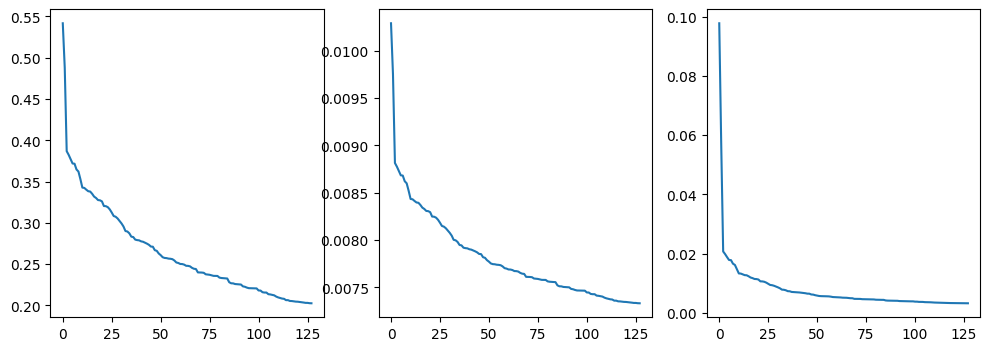

In [82]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(sim)
plt.subplot(1,3,2)
plt.plot(F.softmax(torch.from_numpy(sim)).numpy())
plt.subplot(1,3,3)
plt.plot(F.softmax(torch.from_numpy(sim)*10).numpy())

/tmp/ipykernel_2624111/3406763281.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  plt.plot(F.softmax(torch.from_numpy(sim)).numpy()*50)
/tmp/ipykernel_2624111/3406763281.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  plt.plot(F.softmax(torch.from_numpy(sim)*10).numpy()*5)


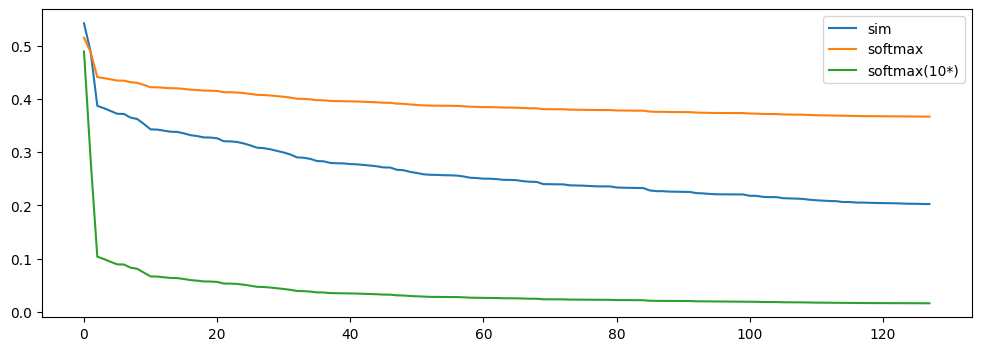

In [86]:
plt.figure(figsize=(12,4))

# plt.subplot(1,3,1)
plt.plot(sim)
# plt.subplot(1,3,2)
plt.plot(F.softmax(torch.from_numpy(sim)).numpy()*50)
# plt.subplot(1,3,3)
plt.plot(F.softmax(torch.from_numpy(sim)*10).numpy()*5)
plt.legend(["sim","softmax","softmax(10*)"])

# Uncetainty vs. TP/FP Analysis

In [342]:
import numpy as np
from prettytable import PrettyTable
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt


def rank(similarity, q_pids, g_pids, max_rank=10, get_mAP=True):
    if get_mAP:
        indices = torch.argsort(similarity, dim=1, descending=True)
    else:
        # acclerate sort with topk
        _, indices = torch.topk(
            similarity, k=max_rank, dim=1, largest=True, sorted=True
        )  # q * topk
    pred_labels = g_pids[indices.cpu()]  # q * k
    matches = pred_labels.eq(q_pids.view(-1, 1))  # q * k

    all_cmc = matches[:, :max_rank].cumsum(1) # cumulative sum
    all_cmc[all_cmc > 1] = 1
    all_cmc = all_cmc.float().mean(0) * 100
    # all_cmc = all_cmc[topk - 1]

    if not get_mAP:
        return all_cmc, indices

    num_rel = matches.sum(1)  # q
    tmp_cmc = matches.cumsum(1)  # q * k

    inp = [tmp_cmc[i][match_row.nonzero()[-1]] / (match_row.nonzero()[-1] + 1.) for i, match_row in enumerate(matches)]
    mINP = torch.cat(inp).mean() * 100

    tmp_cmc = [tmp_cmc[:, i] / (i + 1.0) for i in range(tmp_cmc.shape[1])]
    tmp_cmc = torch.stack(tmp_cmc, 1) * matches
    AP = tmp_cmc.sum(1) / num_rel  # q
    mAP = AP.mean() * 100

    return all_cmc, mAP, mINP, indices

def computer_metric(similarity, qids, gids, i2t_metric=False):
    t2i_cmc, t2i_mAP, t2i_mINP, _ = rank(similarity=similarity.cpu(), q_pids=qids.cpu(), g_pids=gids.cpu(), max_rank=10, get_mAP=True)
    t2i_cmc, t2i_mAP, t2i_mINP = t2i_cmc.numpy(), t2i_mAP.numpy(), t2i_mINP.numpy()
    table = PrettyTable(["task", "R1", "R5", "R10", "mAP", "mINP"])
    table.add_row(['t2i', t2i_cmc[0], t2i_cmc[4], t2i_cmc[9], t2i_mAP, t2i_mINP])

    if i2t_metric:
        i2t_cmc, i2t_mAP, i2t_mINP, _ = rank(similarity=similarity.cpu().t(), q_pids=gids.cpu(), g_pids=qids.cpu(), max_rank=10, get_mAP=True)
        i2t_cmc, i2t_mAP, i2t_mINP = i2t_cmc.numpy(), i2t_mAP.numpy(), i2t_mINP.numpy()
        table.add_row(['i2t', i2t_cmc[0], i2t_cmc[4], i2t_cmc[9], i2t_mAP, i2t_mINP])
    # table.float_format = '.4'
    table.custom_format["R1"] = lambda f, v: f"{v:.3f}"
    table.custom_format["R5"] = lambda f, v: f"{v:.3f}"
    table.custom_format["R10"] = lambda f, v: f"{v:.3f}"
    table.custom_format["mAP"] = lambda f, v: f"{v:.3f}"
    table.custom_format["mINP"] = lambda f, v: f"{v:.3f}"
    print(str(table))

    eval_result = {
        'R1': t2i_cmc[0],
        'R5': t2i_cmc[4],
        'R10': t2i_cmc[9],
        'mAP': t2i_mAP,
        'mINP': t2i_mINP,
    }

    return eval_result

## cmp_pab_tta debug_embeddings

In [343]:
sims_matrix_t2i_npy_wo_norm = np.load('data/debug_embeddings/sims_matrix_t2i_wo_norm.npy')
sims_matrix_t2i_npy = np.load('data/debug_embeddings/sims_matrix_t2i.npy')
q_pids = np.load("data/debug_embeddings/q_pids.npy")
g_pids = np.load("data/debug_embeddings/g_pids.npy")

## origin score

In [344]:
eval_result = computer_metric(
    torch.from_numpy(sims_matrix_t2i_npy),
    torch.from_numpy(q_pids),
    torch.from_numpy(g_pids)
)

eval_result_wo_norm = computer_metric(
    torch.from_numpy(sims_matrix_t2i_npy_wo_norm),
    torch.from_numpy(q_pids),
    torch.from_numpy(g_pids)
)

+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 69.414 | 95.197 | 97.776 | 81.233 | 81.233 |
+------+--------+--------+--------+--------+--------+
+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 58.544 | 91.860 | 95.703 | 73.596 | 73.596 |
+------+--------+--------+--------+--------+--------+


## 两种sample_selection的itc score

In [345]:
def sample_selection_itc(sims_matrix_t2i, sims_matrix_i2t):
    # find_inter_top1_sample_selection
    ss_idxs_list = []
    for i, sims_t2i in enumerate(sims_matrix_t2i):
        top1_sim_t2i, top1_idx_t2i = sims_t2i.topk(k=1, dim=0) # 获取t2i top1的相似度(top1_sim_t2i)和索引(top1_idx_t2i)
        top1_sim_i2t, top1_idx_i2t  = sims_matrix_i2t[top1_idx_t2i][0].topk(k=1, dim=0) # 获取top1_idx_t2i对应的i2t相似度和索引
        if top1_idx_i2t == i: # 只保留t2i和i2t互为top1的样本
            ss_idxs_list.append(i)
        # else:
        #     print(f"t2i & i2t do not have inter top1 sample: i2t_idx={i}, t2i_idx={top1_idx_t2i}, top1_sim_i2t={top1_sim_i2t}, top1_sim_t2i={top1_sim_t2i}")

    return ss_idxs_list

ss_idxs_list = sample_selection_itc(torch.from_numpy(sims_matrix_t2i_npy), torch.from_numpy(sims_matrix_t2i_npy).t())

ss_idxs_list_wo_ssnorm = sample_selection_itc(torch.from_numpy(sims_matrix_t2i_npy_wo_norm), torch.from_numpy(sims_matrix_t2i_npy_wo_norm).t())

In [346]:
eval_result = computer_metric(
    torch.from_numpy(sims_matrix_t2i_npy[ss_idxs_list]),
    torch.from_numpy(q_pids[ss_idxs_list]),
    torch.from_numpy(g_pids)
)
eval_result_wo_ssnorm = computer_metric(
    torch.from_numpy(sims_matrix_t2i_npy[ss_idxs_list_wo_ssnorm]),
    torch.from_numpy(q_pids[ss_idxs_list_wo_ssnorm]),
    torch.from_numpy(g_pids)
)

eval_result_wo_norm = computer_metric(
    torch.from_numpy(sims_matrix_t2i_npy_wo_norm[ss_idxs_list]),
    torch.from_numpy(q_pids[ss_idxs_list]),
    torch.from_numpy(g_pids)
)

eval_result_wo_norm_wo_ssnorm = computer_metric(
    torch.from_numpy(sims_matrix_t2i_npy_wo_norm[ss_idxs_list_wo_ssnorm]),
    torch.from_numpy(q_pids[ss_idxs_list_wo_ssnorm]),
    torch.from_numpy(g_pids)
)

+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 86.953 | 98.727 | 99.602 | 92.588 | 92.588 |
+------+--------+--------+--------+--------+--------+
+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 86.563 | 99.221 | 99.903 | 92.557 | 92.557 |
+------+--------+--------+--------+--------+--------+
+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 73.031 | 97.693 | 99.125 | 84.496 | 84.496 |
+------+--------+--------+--------+--------+--------+
+------+--------+--------+--------+--------+--------+
| task |   R1   |   R5   |  R10   |  mAP   |  mINP  |
+------+--------+--------+--------+--------+--------+
| t2i  | 85.589 | 98.345 | 9

## New Uncertainty Design - cos_sim

In [250]:
def compute_uncertainty_itc(sims_matrix_t2i, sims_matrix_i2t, uncertainty_temper=1.0, uncertainty_t2i_temper=1.0, uncertainty_i2t_temper=1.0, k_test = 128):
    uncertaintys_list = []
    uncertainty2_list = []
    uncertainty3_list = []
    uncertainty4_list = []
    proba_top1_sim_list = []
    proba_inversed_sim_list = []
    for i, sims_t2i in enumerate(sims_matrix_t2i):

        topk_sim_t2i, topk_idx_t2i = sims_t2i.topk(k=k_test, dim=0)
        proba_top1_sim_t2i = F.softmax(topk_sim_t2i * uncertainty_t2i_temper, dim=0)[0] # i2t和t2i的logtis rank/distribution呈现长尾or平均的现象

        proba_inversed_sim_i2t_top1_idx_t2i = torch.zeros([])
        topk_sim_i2t_top1_idx_t2i, topk_idx_i2t_top1_idx_t2i = sims_matrix_i2t[topk_idx_t2i[0]].topk(k=k_test, dim=0)
        if i in topk_idx_i2t_top1_idx_t2i:
            idx_i_in_topk_idx_i2t_top1_idx_t2i = torch.where(topk_idx_i2t_top1_idx_t2i == i)[0][0]
            proba_inversed_sim_i2t_top1_idx_t2i = F.softmax(topk_sim_i2t_top1_idx_t2i * uncertainty_i2t_temper, dim=0)[idx_i_in_topk_idx_i2t_top1_idx_t2i]

        uncertainty = torch.exp( (1 - (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) / 2) * uncertainty_temper ) #之前
        uncertainty2 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper )
        uncertainty3 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / ((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        uncertainty4 = torch.abs( torch.log(proba_top1_sim_t2i + 1e-2) - torch.log( proba_inversed_sim_i2t_top1_idx_t2i + 1e-2) )

        uncertaintys_list.append(uncertainty)
        uncertainty2_list.append(uncertainty2)
        uncertainty3_list.append(uncertainty3)
        uncertainty4_list.append(uncertainty4)
        proba_top1_sim_list.append(proba_top1_sim_t2i)
        proba_inversed_sim_list.append(proba_inversed_sim_i2t_top1_idx_t2i)
    return uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, proba_top1_sim_list, proba_inversed_sim_list

In [313]:
### hyper-parameters of uncertainty
uncertainty_temper = 1
uncertainty_t2i_temper = 1
uncertainty_i2t_temper = 1
k_test = 128

### get cos_sims_matrix
# sims_matrix_t2i = F.normalize(torch.from_numpy(sims_matrix_t2i_npy),p=2,dim=-1)# / 0.02

sims_matrix_t2i = torch.from_numpy(sims_matrix_t2i_npy) / 0.03
### get labels
gids = torch.from_numpy(g_pids)
qids = torch.from_numpy(q_pids)

### compute uncertainty
uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, proba_top1_sim_list, proba_inversed_sim_list = compute_uncertainty_itc(sims_matrix_t2i, sims_matrix_t2i.t(), uncertainty_temper, uncertainty_t2i_temper, uncertainty_i2t_temper, k_test)
# uncertaintys_list, uncertainty2_list, uncertainty3_list, uncertainty4_list, proba_top1_sim_list, proba_inversed_sim_list = compute_uncertainty_itc(qfeats, gfeats, sims_matrix_t2i_norm, sims_matrix_t2i_norm.t(), uncertainty_temper, uncertainty_t2i_temper, uncertainty_i2t_temper, k_test)

print(f"len(uncertaintys_list) = {len(uncertaintys_list)}")
print(f"len(uncertainty2_list) = {len(uncertainty2_list)}")
print(f"len(uncertainty3_list) = {len(uncertainty3_list)}")
print(f"len(uncertainty4_list) = {len(uncertainty4_list)}")

print(uncertaintys_list[:10])
print(uncertainty2_list[:10])
print(uncertainty3_list[:10])
print(uncertainty4_list[:10])

len(uncertaintys_list) = 1978
len(uncertainty2_list) = 1978
len(uncertainty3_list) = 1978
len(uncertainty4_list) = 1978
[tensor(1.4211), tensor(1.2337), tensor(2.0962), tensor(1.2749), tensor(1.2032), tensor(1.8005), tensor(1.5075), tensor(1.9352), tensor(1.3102), tensor(1.8583)]
[tensor(1.4131), tensor(1.3889), tensor(1.1107), tensor(1.2935), tensor(1.3040), tensor(1.5166), tensor(1.2103), tensor(1.3640), tensor(1.1025), tensor(1.4718)]
[tensor(1.7042), tensor(1.5156), tensor(1.4980), tensor(1.4049), tensor(1.3850), tensor(2.7486), tensor(1.3822), tensor(2.4932), tensor(1.1430), tensor(2.7626)]
[tensor(0.5376), tensor(0.4166), tensor(0.3942), tensor(0.3387), tensor(0.3246), tensor(1.0815), tensor(0.3210), tensor(0.9537), tensor(0.1321), tensor(1.0855)]


### 可视化 uncertainty

TP_uncertainty.stats: len=1373, mean=1.3155215978622437, max=2.5346577167510986, min=1.000635027885437, std=0.29154908657073975
FP_uncertainty.stats: len=605, mean=1.82986581325531, max=2.5473456382751465, min=1.0426111221313477, std=0.3463248014450073


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

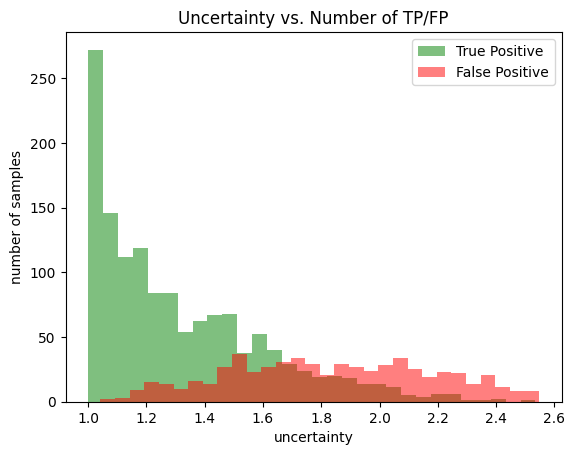

In [314]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertaintys_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

### 可视化 uncertainty2

TP_uncertainty.stats: len=1373, mean=1.2512625455856323, max=2.4431822299957275, min=1.0000702142715454, std=0.27724489569664
FP_uncertainty.stats: len=605, mean=1.4495575428009033, max=2.461534023284912, min=1.0022097826004028, std=0.33075210452079773


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

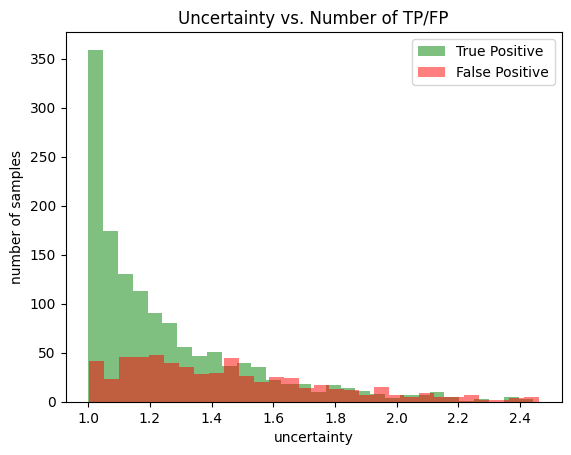

In [315]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty2_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

### 可视化 uncertainty3

TP_uncertainty.stats: len=1373, mean=1.6293590068817139, max=7.2718963623046875, min=1.000070333480835, std=1.0634573698043823
FP_uncertainty.stats: len=605, mean=3.569634437561035, max=7.387715816497803, min=1.0033222436904907, std=2.196730852127075


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

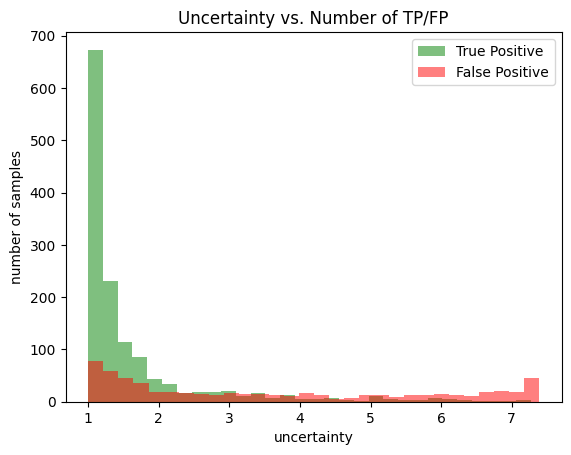

In [317]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty3_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

### 调参：根据Uncertainty3的tp/fp分布

#### 结论：sims_mat的数值大小决定了分布的情况
- HAM中计算uncertainty使用的sims_mat由未经过norm的img_feature和text_feature计算得到，sims_mat整体数值偏大
- CMP中计算uncertainty使用的sims_mat由经过norm的img_feature和text_feature计算得到，sims_mat整体数值偏小
- 为了统一，CMP计算uncertainty前，先将sims_mat除以一个0.03的temperature放大数值
- 这里的0.03与 （在HAM中计算entropy之前，先将img_feature和text_feature进行norm再把cos_sims除以0.02的temperature得到cos_sims_inter） 的作用相似

In [318]:
print(qids)
print(gids)
print((qids == gids).sum())

tensor([   0,    1,    2,  ..., 1975, 1976, 1977])
tensor([   0,    1,    2,  ..., 1975, 1976, 1977])
tensor(1978)


In [319]:
sims.shape

torch.Size([1978, 128])

In [320]:
sims, idxs = sims_matrix_t2i.topk(k=128, dim=-1)

In [321]:
sims.mean(), sims.max(), sims.min(), sims.std()

(tensor(7.5729), tensor(23.9409), tensor(1.4769), tensor(2.6156))

In [322]:
sims[:,0].mean(), sims[:,1].mean(), sims[:,:5].mean(), sims[:,5:16].mean(), sims[:,-1].mean()

(tensor(18.1618),
 tensor(16.0138),
 tensor(14.6445),
 tensor(10.6233),
 tensor(5.5914))

In [323]:
sims[:,0]

tensor([18.0565, 19.5257, 16.3207,  ..., 19.6996, 20.4207, 20.3527])

In [324]:
print((gids[idxs[:,0]] != qids).sum())
print((1978-(idxs[:,0] != qids).sum())/1978)

tensor(605)
tensor(0.6941)


In [325]:
[gids[idxs[:,0]] != qids]

[tensor([False, False,  True,  ..., False, False, False])]

In [337]:
uncertainty_temper = 1
uncertainty_t2i_temper = 1
uncertainty_i2t_temper = 1
k_test = 128

sims_matrix_t2i = torch.from_numpy(sims_matrix_t2i_npy) / 0.03
sims_matrix_i2t = sims_matrix_t2i.t()

tp_uncertaintys_list = []
tp_uncertainty2_list = []
tp_uncertainty3_list = []
tp_uncertainty4_list = []
tp_proba_top1_sim_list = []
tp_proba_inversed_sim_list = []
tp_idx_inversed_sim_list = []

fp_uncertaintys_list = []
fp_uncertainty2_list = []
fp_uncertainty3_list = []
fp_uncertainty4_list = []
fp_proba_top1_sim_list = []
fp_proba_inversed_sim_list = []
fp_idx_inversed_sim_list = []
for i, sims_t2i in enumerate(sims_matrix_t2i):

    topk_sim_t2i, topk_idx_t2i = sims_t2i.topk(k=k_test, dim=0)
    if gids[topk_idx_t2i[0]] != qids[i]:
        proba_top1_sim_t2i = F.softmax(topk_sim_t2i * uncertainty_t2i_temper, dim=0)[0] # i2t和t2i的logtis rank/distribution呈现长尾or平均的现象

        proba_inversed_sim_i2t_top1_idx_t2i = torch.zeros([])
        topk_sim_i2t_top1_idx_t2i, topk_idx_i2t_top1_idx_t2i = sims_matrix_i2t[topk_idx_t2i[0]].topk(k=k_test, dim=0)
        if i in topk_idx_i2t_top1_idx_t2i:
            idx_i_in_topk_idx_i2t_top1_idx_t2i = torch.where(topk_idx_i2t_top1_idx_t2i == i)[0][0]
            proba_inversed_sim_i2t_top1_idx_t2i = F.softmax(topk_sim_i2t_top1_idx_t2i * uncertainty_i2t_temper, dim=0)[idx_i_in_topk_idx_i2t_top1_idx_t2i]

        uncertainty = torch.exp( (1 - (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) / 2) * uncertainty_temper ) #之前
        uncertainty2 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper )
        uncertainty3 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / ((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        uncertainty4 = torch.abs( torch.log(proba_top1_sim_t2i + 1e-2) - torch.log( proba_inversed_sim_i2t_top1_idx_t2i + 1e-2) )

        fp_uncertaintys_list.append(uncertainty)
        fp_uncertainty2_list.append(uncertainty2)
        fp_uncertainty3_list.append(uncertainty3)
        fp_uncertainty4_list.append(uncertainty4)
        fp_proba_top1_sim_list.append(proba_top1_sim_t2i)
        fp_proba_inversed_sim_list.append(proba_inversed_sim_i2t_top1_idx_t2i)
        fp_idx_inversed_sim_list.append(idx_i_in_topk_idx_i2t_top1_idx_t2i)

    if gids[topk_idx_t2i[0]] == qids[i]:
        proba_top1_sim_t2i = F.softmax(topk_sim_t2i * uncertainty_t2i_temper, dim=0)[0] # i2t和t2i的logtis rank/distribution呈现长尾or平均的现象

        proba_inversed_sim_i2t_top1_idx_t2i = torch.zeros([])
        topk_sim_i2t_top1_idx_t2i, topk_idx_i2t_top1_idx_t2i = sims_matrix_i2t[topk_idx_t2i[0]].topk(k=k_test, dim=0)
        if i in topk_idx_i2t_top1_idx_t2i:
            idx_i_in_topk_idx_i2t_top1_idx_t2i = torch.where(topk_idx_i2t_top1_idx_t2i == i)[0][0]
            proba_inversed_sim_i2t_top1_idx_t2i = F.softmax(topk_sim_i2t_top1_idx_t2i * uncertainty_i2t_temper, dim=0)[idx_i_in_topk_idx_i2t_top1_idx_t2i]

        uncertainty = torch.exp( (1 - (proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i) / 2) * uncertainty_temper ) #之前
        uncertainty2 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) * uncertainty_temper )
        uncertainty3 = torch.exp( torch.abs(proba_top1_sim_t2i - proba_inversed_sim_i2t_top1_idx_t2i) / ((proba_top1_sim_t2i + proba_inversed_sim_i2t_top1_idx_t2i)/2) * uncertainty_temper )
        uncertainty4 = torch.abs( torch.log(proba_top1_sim_t2i + 1e-2) - torch.log( proba_inversed_sim_i2t_top1_idx_t2i + 1e-2) )

        tp_uncertaintys_list.append(uncertainty)
        tp_uncertainty2_list.append(uncertainty2)
        tp_uncertainty3_list.append(uncertainty3)
        tp_uncertainty4_list.append(uncertainty4)
        tp_proba_top1_sim_list.append(proba_top1_sim_t2i)
        tp_proba_inversed_sim_list.append(proba_inversed_sim_i2t_top1_idx_t2i)
        tp_idx_inversed_sim_list.append(idx_i_in_topk_idx_i2t_top1_idx_t2i)


In [338]:
print(tp_uncertainty3_list)
print(np.mean(tp_uncertainty3_list),np.max(tp_uncertainty3_list),np.min(tp_uncertainty3_list),np.std(tp_uncertainty3_list))
print(len(tp_uncertainty3_list))
print(tp_proba_top1_sim_list)
print(np.mean(tp_proba_top1_sim_list),np.max(tp_proba_top1_sim_list),np.min(tp_proba_top1_sim_list),np.std(tp_proba_top1_sim_list))
print(tp_proba_inversed_sim_list)
print(np.mean(tp_proba_inversed_sim_list),np.max(tp_proba_inversed_sim_list),np.min(tp_proba_inversed_sim_list),np.std(tp_proba_inversed_sim_list))
print(tp_idx_inversed_sim_list)
print(np.mean(tp_idx_inversed_sim_list),np.max(tp_idx_inversed_sim_list),np.min(tp_idx_inversed_sim_list),np.std(tp_idx_inversed_sim_list))

[tensor(1.7042), tensor(1.5156), tensor(1.3850), tensor(2.7486), tensor(2.7626), tensor(2.5628), tensor(1.0336), tensor(1.0331), tensor(1.0391), tensor(1.1598), tensor(6.5446), tensor(1.0748), tensor(1.6178), tensor(1.8626), tensor(1.3067), tensor(1.4332), tensor(1.5550), tensor(1.1621), tensor(1.4816), tensor(1.0579), tensor(4.3718), tensor(1.0533), tensor(1.0079), tensor(1.0609), tensor(1.0148), tensor(1.0544), tensor(1.4535), tensor(3.6947), tensor(1.3902), tensor(1.3538), tensor(1.0583), tensor(1.4539), tensor(1.0950), tensor(1.0359), tensor(1.2938), tensor(1.1150), tensor(3.4700), tensor(1.0874), tensor(1.1595), tensor(1.1533), tensor(1.1096), tensor(4.2509), tensor(1.0249), tensor(1.3180), tensor(1.5192), tensor(3.3638), tensor(1.4380), tensor(1.0046), tensor(1.3026), tensor(1.3345), tensor(1.0266), tensor(1.0993), tensor(3.1095), tensor(1.8414), tensor(1.0067), tensor(1.2229), tensor(2.2286), tensor(1.0102), tensor(3.3183), tensor(1.1255), tensor(1.0026), tensor(1.0054), tensor(

In [339]:
print(fp_uncertainty3_list)
print(np.mean(fp_uncertainty3_list),np.max(fp_uncertainty3_list),np.min(fp_uncertainty3_list),np.std(fp_uncertainty3_list))
print(len(fp_uncertainty3_list))
print(fp_proba_top1_sim_list)
print(np.mean(fp_proba_top1_sim_list),np.max(fp_proba_top1_sim_list),np.min(fp_proba_top1_sim_list),np.std(fp_proba_top1_sim_list))
print(fp_proba_inversed_sim_list)
print(np.mean(fp_proba_inversed_sim_list),np.max(fp_proba_inversed_sim_list),np.min(fp_proba_inversed_sim_list),np.std(fp_proba_inversed_sim_list))
print(fp_idx_inversed_sim_list)
print(np.mean(fp_idx_inversed_sim_list),np.max(fp_idx_inversed_sim_list),np.min(fp_idx_inversed_sim_list),np.std(fp_idx_inversed_sim_list))

[tensor(1.4980), tensor(1.4049), tensor(1.3822), tensor(2.4932), tensor(1.1430), tensor(7.3206), tensor(6.0470), tensor(2.8722), tensor(1.5675), tensor(1.8390), tensor(2.3825), tensor(2.1653), tensor(1.3610), tensor(1.9299), tensor(6.3241), tensor(7.3514), tensor(7.3111), tensor(3.7228), tensor(1.1443), tensor(1.2866), tensor(7.3725), tensor(1.5451), tensor(3.2932), tensor(5.8031), tensor(5.9112), tensor(3.8706), tensor(1.6217), tensor(1.1544), tensor(2.1678), tensor(7.3833), tensor(3.5635), tensor(6.8674), tensor(1.1526), tensor(1.0473), tensor(1.5186), tensor(6.1771), tensor(6.9084), tensor(1.4250), tensor(1.3838), tensor(2.9653), tensor(1.3537), tensor(1.0200), tensor(2.6143), tensor(1.0569), tensor(6.0841), tensor(4.0606), tensor(1.0141), tensor(1.4686), tensor(4.2002), tensor(5.1797), tensor(2.1711), tensor(1.7290), tensor(2.6289), tensor(1.2947), tensor(7.3877), tensor(2.5582), tensor(4.7986), tensor(3.6699), tensor(4.1917), tensor(5.1792), tensor(4.3544), tensor(1.1751), tensor(

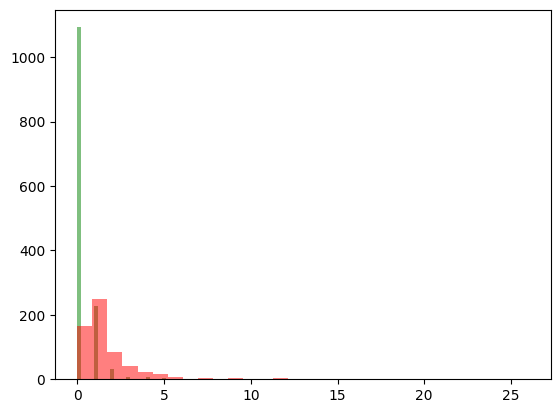

In [340]:
plt.figure()
hist_info_TP = plt.hist(tp_idx_inversed_sim_list, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(fp_idx_inversed_sim_list, bins=30, alpha=0.5, color='red')

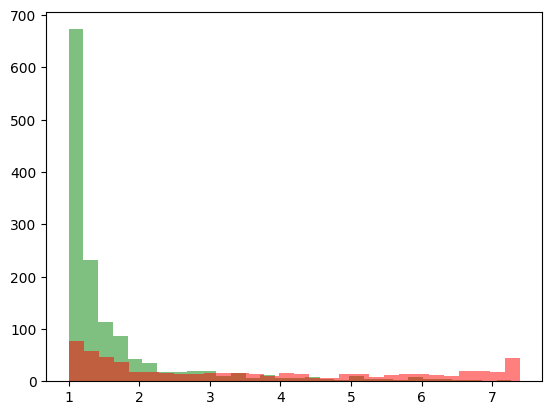

In [341]:
plt.figure()
hist_info_TP = plt.hist(tp_uncertainty3_list, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(fp_uncertainty3_list, bins=30, alpha=0.5, color='red')

### 可视化 uncertainty4

TP_uncertainty.stats: len=1373, mean=0.40908148884773254, max=3.879164218902588, min=6.958562880754471e-05, std=0.5801196098327637
FP_uncertainty.stats: len=605, mean=1.437451720237732, max=4.291268348693848, min=0.003278210759162903, std=1.14642333984375


Text(0.5, 1.0, 'Uncertainty vs. Number of TP/FP')

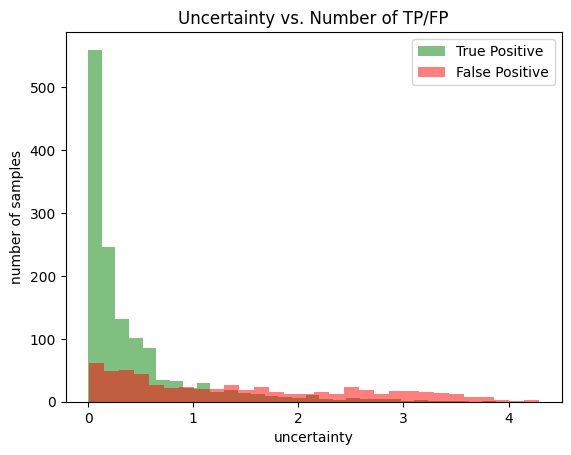

In [331]:
### plot uncertainty vs. TP/FP
TP_unc = []
FP_unc = []
for sample_idx, (sims_t2i, unc) in enumerate(zip(sims_matrix_t2i, uncertainty4_list)):
    sims_topk, idx_topk = sims_t2i.topk(k=128, dim=-1)
    if gids[idx_topk[0].numpy()] == qids[sample_idx]:
        TP_unc.append(unc)
    else:
        FP_unc.append(unc)

print(f"TP_uncertainty.stats: len={len(TP_unc)}, mean={np.mean(TP_unc)}, max={np.max(TP_unc)}, min={np.min(TP_unc)}, std={ np.std(TP_unc)}")
print(f"FP_uncertainty.stats: len={len(FP_unc)}, mean={np.mean(FP_unc)}, max={np.max(FP_unc)}, min={np.min(FP_unc)}, std={ np.std(FP_unc)}")

plt.figure()
hist_info_TP = plt.hist(TP_unc, bins=30, alpha=0.5, color='green')
hist_info_FP = plt.hist(FP_unc, bins=30, alpha=0.5, color='red')
plt.legend(['True Positive', 'False Positive'])
plt.xlabel('uncertainty')
plt.ylabel('number of samples')
plt.title('Uncertainty vs. Number of TP/FP')

# Todo

In [18]:
assert True, "aaaaa"